厳密解法(Jacobian)でLLEを計算中...
Progress: 0/80000, Current LLE: 0.0000
Progress: 10000/80000, Current LLE: 0.0117
Progress: 20000/80000, Current LLE: 0.0101
Progress: 30000/80000, Current LLE: 0.0098
Progress: 40000/80000, Current LLE: 0.0086
Progress: 50000/80000, Current LLE: 0.0072
Progress: 60000/80000, Current LLE: 0.0064
Progress: 70000/80000, Current LLE: 0.0057
------------------------------
確定した最大リアプノフ指数: 0.005529
------------------------------


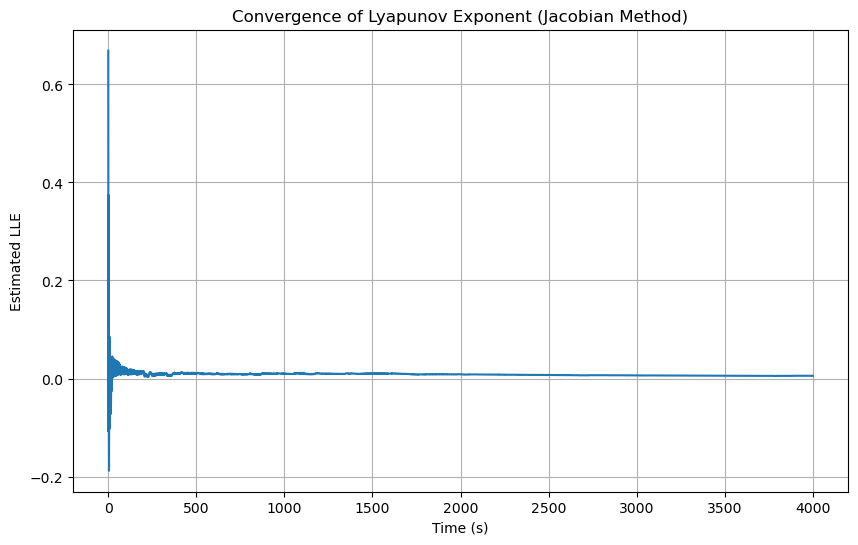

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [14]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. パラメータ設定 (元のまま)
params = {
    'r': [1.5, 1.0, 1.0, 1.0],
    'lambda': [[0.2, 0.3],
               [0.3, 0.1]],
    'c': [0.8, 0.6],
    'd': [0.6, 0.8]
}

# 2. ヤコビ行列を含むモデル定義
# カオス計算のために、状態(4変数)と、接ベクトル(4変数)を同時に解きます
def model_with_tangent(z_all, t, params):
    # 状態変数 (x:被食者, y:捕食者)
    x1, y1, x2, y2 = z_all[:4]
    # 接ベクトル (w: 微小なズレ)
    w = z_all[4:]
    
    r_x1, r_y1, r_x2, r_y2 = params['r']
    lam = params['lambda']
    c = params['c']
    d = params['d']
    
    l11, l12 = lam[0]
    l21, l22 = lam[1]
    c1, c2 = c
    d1, d2 = d

    # --- 元の方程式 (d_state / dt) ---
    dx1dt = r_x1*x1 - l11*x1*y1 - l12*x1*y2
    dx2dt = r_x2*x2 - l21*x2*y1 - l22*x2*y2
    dy1dt = -r_y1*y1 + c1*l11*x1*y1 + d1*l21*x2*y1
    dy2dt = -r_y2*y2 + c2*l12*x1*y2 + d2*l22*x2*y2
    
    # --- ヤコビ行列 J (4x4) の計算 ---
    # J[i, j] = d(f_i) / d(state_j)
    # 行: dx1, dy1, dx2, dy2
    # 列: x1,  y1,  x2,  y2  (注意: 元のコードの並び z=[x1, y1, x2, y2] に合わせる)
    
    J = np.zeros((4, 4))
    
    # 1. dx1/dt の微分
    J[0, 0] = r_x1 - l11*y1 - l12*y2  # d/dx1
    J[0, 1] = -l11*x1                 # d/dy1
    J[0, 2] = 0                       # d/dx2
    J[0, 3] = -l12*x1                 # d/dy2
    
    # 2. dy1/dt の微分
    J[1, 0] = c1*l11*y1               # d/dx1
    J[1, 1] = -r_y1 + c1*l11*x1 + d1*l21*x2 # d/dy1
    J[1, 2] = d1*l21*y1               # d/dx2
    J[1, 3] = 0                       # d/dy2

    # 3. dx2/dt の微分
    J[2, 0] = 0                       # d/dx1
    J[2, 1] = -l21*x2                 # d/dy1
    J[2, 2] = r_x2 - l21*y1 - l22*y2  # d/dx2
    J[2, 3] = -l22*x2                 # d/dy2
    
    # 4. dy2/dt の微分
    J[3, 0] = c2*l12*y2               # d/dx1
    J[3, 1] = 0                       # d/dy1
    J[3, 2] = d2*l22*y2               # d/dx2
    J[3, 3] = -r_y2 + c2*l12*x1 + d2*l22*x2 # d/dy2

    # 接ベクトルの時間発展: dw/dt = J * w
    dwdt = J @ w
    
    return [dx1dt, dy1dt, dx2dt, dy2dt, dwdt[0], dwdt[1], dwdt[2], dwdt[3]]

# 3. リアプノフ指数の計算ループ (Benettin algorithm)
print("厳密解法(Jacobian)でLLEを計算中...")

# 時間設定
t_max = 4000
dt = 0.05
steps = int(t_max / dt)

# 初期値
z = np.array([2.0, 2.0, 1.5, 1.5]) # 状態
w = np.array([1.0, 0.0, 0.0, 0.0]) # 接ベクトル初期値（長さ1）
w = w / np.linalg.norm(w)

cum_log_norm = 0.0
lle_history = []

# 過渡応答を捨てる期間（最初の数秒）
transient_steps = 1000

for i in range(steps):
    # 1ステップだけ積分
    t_span = [0, dt]
    z_all_init = np.concatenate([z, w])
    sol = odeint(model_with_tangent, z_all_init, t_span, args=(params,))
    
    z_next = sol[-1, :4]
    w_next = sol[-1, 4:]
    
    # ノルム（拡大率）の計算
    d_norm = np.linalg.norm(w_next)
    
    # 過渡応答期間を過ぎたら記録開始
    if i > transient_steps:
        cum_log_norm += np.log(d_norm)
        # 現在のLLE推定値 (平均化)
        current_time = (i - transient_steps) * dt
        lle = cum_log_norm / current_time
        lle_history.append(lle)
    
    # 接ベクトルの正規化（大きさを1に戻す）
    z = z_next
    w = w_next / d_norm

    if i % 10000 == 0:
        print(f"Progress: {i}/{steps}, Current LLE: {lle_history[-1] if len(lle_history)>0 else 0:.4f}")

final_lle = lle_history[-1]
print("-" * 30)
print(f"確定した最大リアプノフ指数: {final_lle:.6f}")
print("-" * 30)

# 収束の様子をプロット
plt.figure(figsize=(10, 6))
plt.plot(np.linspace(0, t_max, len(lle_history)), lle_history)
plt.xlabel('Time (s)')
plt.ylabel('Estimated LLE')
plt.title('Convergence of Lyapunov Exponent (Jacobian Method)')
plt.grid(True)
plt.show()
# 軌道の可視化コード


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.spatial import KDTree
from scipy.signal import find_peaks

# 1. モデル方程式の定義
def model(z, t, params):
    x1, y1, x2, y2 = z
    r_x1, r_y1, r_x2, r_y2 = params['r']
    lam = params['lambda']
    c = params['c']
    d = params['d']
    
    # 係数の展開
    l11, l12 = lam[0]
    l21, l22 = lam[1]
    c1, c2 = c
    d1, d2 = d
    
    # 修正版方程式：x=被食者、y=捕食者
    # 元のコードの構造（xとyの役割）を完全に入れ替えています。
    
    # --- 被食者 (Prey) の式: x1, x2 ---
    # 元の y の式（自然増 - 捕食死）の構造を適用
    # c, d (変換効率) はここには含まれません。
    dx1dt = r_x1*x1 - l11*x1*y1 - l12*x1*y2
    dx2dt = r_x2*x2 - l21*x2*y1 - l22*x2*y2

    # --- 捕食者 (Predator) の式: y1, y2 ---
    # 元の x の式（自然減 + 捕食増）の構造を適用
    # c, d (変換効率) はこちらに含まれます。
    dy1dt = -r_y1*y1 + c1*l11*x1*y1 + d1*l21*x2*y1
    dy2dt = -r_y2*y2 + c2*l12*x1*y2 + d2*l22*x2*y2
    
    return [dx1dt, dy1dt, dx2dt, dy2dt]

def calculate_lle_wolf_fast(data, m, tau, dt, evol_steps):
    N = len(data)
    M = N - (m - 1) * tau
    if M <= evol_steps * 2: return None

    indices = np.arange(M)[:, None] + np.arange(m) * tau
    phase_space = data[indices]
    
    # 空間割り当て木（KDTree）の構築
    tree = KDTree(phase_space)
    
    fiducial_idx = 0
    theiler_window = tau * m
    max_safe_idx = M - evol_steps - 1
    
    # 初期近傍点の探索
    dists, cand_idxs = tree.query(phase_space[fiducial_idx], k=100)
    valid = np.abs(cand_idxs - fiducial_idx) > theiler_window
    if not np.any(valid):
        nn_idx = (fiducial_idx + theiler_window + 1) % max_safe_idx
    else:
        nn_idx = cand_idxs[valid][0]
    
    L_initial = np.linalg.norm(phase_space[fiducial_idx] - phase_space[nn_idx])
    sum_log_growth = 0
    count = 0
    while fiducial_idx < max_safe_idx:
        prev_nn_idx = nn_idx
        fiducial_idx += evol_steps
        nn_idx += evol_steps
        
        if nn_idx >= M or fiducial_idx >= M: break
            
        L_prime = np.linalg.norm(phase_space[fiducial_idx] - phase_space[nn_idx])
        
        if L_prime > 0 and L_initial > 0:
            sum_log_growth += np.log2(L_prime / L_initial)
            count += 1
            
        # 置き換え
        old_vector = phase_space[nn_idx] - phase_space[fiducial_idx]
        dists, cand_idxs = tree.query(phase_space[fiducial_idx], k=100)
        valid_mask = (cand_idxs < max_safe_idx) & (np.abs(cand_idxs - fiducial_idx) > theiler_window)
        valid_idxs = cand_idxs[valid_mask]
        
        if len(valid_idxs) == 0: break
            
        cand_vectors = phase_space[valid_idxs] - phase_space[fiducial_idx]
        cand_dists = dists[valid_mask]
        dot_products = np.sum(cand_vectors * old_vector, axis=1)
        norms = cand_dists * (np.linalg.norm(old_vector) + 1e-10)
        cos_thetas = np.clip(dot_products / norms, -1.0, 1.0)
        angles = np.arccos(cos_thetas)
        
        scores = cand_dists + (angles * L_prime)
        best_local_idx = np.argmin(scores)
        nn_idx = valid_idxs[best_local_idx]
        L_initial = cand_dists[best_local_idx]
        if L_initial == 0: L_initial = 1e-10

    return sum_log_growth / (count * evol_steps * dt)

# 2. パラメータ設定 (元のまま)
params = {
    'r': [1.5, 1.0, 1.0, 1.0],
    'lambda': [[0.8, 0.3],
               [0.3, 0.8]],
    'c': [0.8, 0.6],
    'd': [0.6, 0.8]
}

# 初期状態
z0 = [2.0, 2.0, 1.5, 1.5] # [x1, y1, x2, y2]

# 時間軸
t = np.linspace(0, 400, 10000)
dt = t[1] - t[0]  # これにより dt = 0.08016... が得られます

# 3. 微分方程式を解く
z = odeint(model, z0, t, args=(params,))



x1 = z[:, 0]
y1 = z[:, 1]
x2 = z[:, 2]
y2 = z[:, 3]

# --- ここから追加 ---
print("リアプノフ指数を計算中...")

# 1. 平均周期を求めて evol_steps (Δt) を決める
peaks, _ = find_peaks(x1[5000:]) # 最初の2000点からピーク抽出
if len(peaks) > 1:
    avg_period_steps = np.mean(np.diff(peaks))
    # ウォルフの論文に基づき 0.5T 〜 1.5T の範囲（例: 0.8T）を設定
    evol_steps_val = int(avg_period_steps * 0.8)
else:
    print("デフォルト幅です")
    evol_steps_val = 20 # ピークが見つからない場合のデフォルト値

# 2. LLEの実行 (m=5, tau=10などは標準的な設定)
lle = calculate_lle_wolf_fast(x1, m=5, tau=10, dt=dt, evol_steps=10)

print("-" * 30)
print(f"最大リアプノフ指数 (LLE): {lle:.6f} bit/s")
print("-" * 30)
print(f"{avg_period_steps}")
# --- ここまで追加 ---

# タイトル文字列の生成
r_list = params['r']
lambda_matrix = params['lambda']
c_list = params['c']
d_list = params['d']

full_title = (
    f'4 Species Lotka-Volterra Dynamics (x=Prey, y=Predator)\n'
    f'$r_{{x1}}$={r_list[0]}, $r_{{y1}}$={r_list[1]}, $r_{{x2}}$={r_list[2]}, $r_{{y2}}$={r_list[3]}\n'
    f'$c_1$={c_list[0]}, $d_1$={d_list[0]} | $c_2$={c_list[1]}, $d_2$={d_list[1]}\n'
    f'$\\lambda_{{11}}$={lambda_matrix[0][0]}, $\\lambda_{{12}}$={lambda_matrix[0][1]}, $\\lambda_{{21}}$={lambda_matrix[1][0]}, $\\lambda_{{22}}$={lambda_matrix[1][1]}'
)





リアプノフ指数を計算中...
------------------------------
最大リアプノフ指数 (LLE): 1.215707 bit/s
------------------------------
139.02857142857144


LLE計算開始: Total steps = 2000
Benettin法による最大リアプノフ指数: 0.087040 bits/unit_time


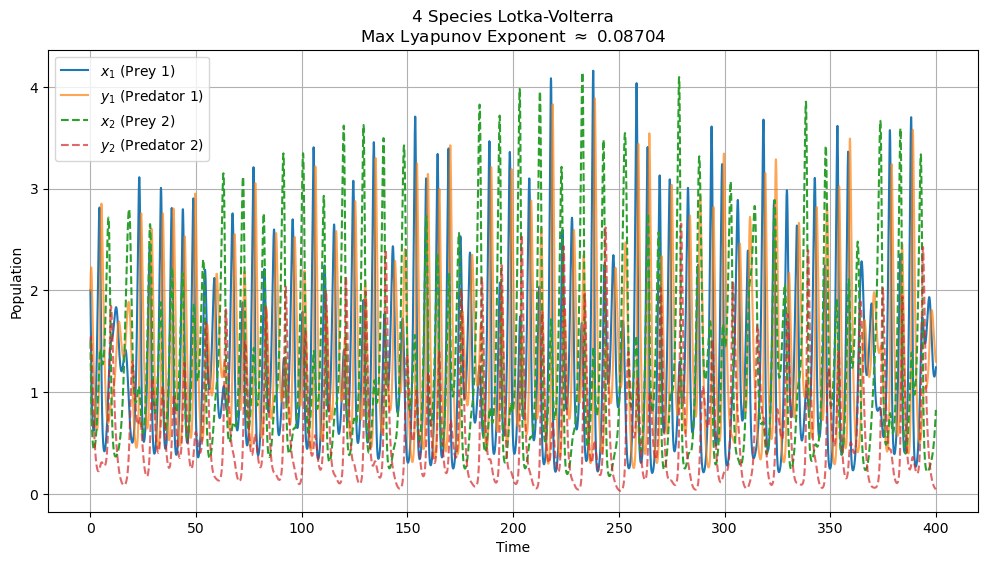

In [1]:
# 4. 可視化
#plt.figure(figsize=(14, 6))

plt.suptitle(
    full_title,
    fontsize=14,
    fontweight='bold',
    y=1.03
)

# --- 図1: 時系列グラフ ---
# x=Prey, y=Predator としてラベル付け
plt.plot(t, x1, label='$x_1$ (Prey 1)')
plt.plot(t, y1, label='$y_1$ (Predator 1)', alpha=0.7)
plt.plot(t, x2, label='$x_2$ (Prey 2)', linestyle='--')
plt.plot(t, y2, label='$y_2$ (Predator 2)', alpha=0.7, linestyle='--')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Time Series')
plt.legend()
plt.grid(True)


plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('lotka_volterra_dynamics_final.png')
plt.show()
# テスト用コード断片
import matplotlib.pyplot as plt
import numpy as np